In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# function to read in the .txt files
def read_txt_to_array(path):
    data = []
    with open(path, "r") as f:
        lines = f.readlines()
    for line in lines[1:]:  # hoppa över rubrik
        line = line.strip()
        if not line:
            continue
        parts = line.replace("(", "").replace(")", "").split(",")
        try:
            x = float(parts[0])
            y = float(parts[1])
            data.append([x, y])
        except ValueError:
            continue
    return np.array(data, dtype=float)

In [ ]:
# saving the txt to arrays
pichu_array = read_txt_to_array("./pika_data/pichu.txt")
pikachu_array = read_txt_to_array("./pika_data/pikachu.txt")

print("Pichu shape:", pichu_array.shape)
print("Pikachu shape:", pikachu_array.shape)

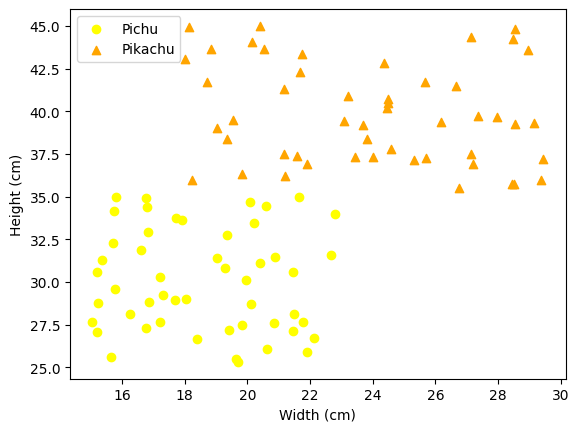

In [42]:
# scatter plot over height and width
# [:,0] and [:,1] splits 2D the array into two 1D arrays
# by taking the first column(width) and placing it into x 
# and the second (length) into y
plt.scatter(pichu_array[:,0], pichu_array[:,1], label="Pichu", color="yellow", marker="o")
plt.scatter(pikachu_array[:,0], pikachu_array[:,1], label="Pikachu", color="orange", marker="^")
plt.xlabel("Width (cm)")
plt.ylabel("Height (cm)")
plt.legend();

In [ ]:
# read in the test data
with open("./pika_data/test_points.txt") as f:
    line = f.readline()

replace = line.replace("(","").replace(")", "").split(",")

test_array = np.array(replace, dtype = float).reshape(-1, 2)
print(test_array)

In [ ]:
# stacking the data points together into one training set
# creates a label array where 0 = pichu and 1 = pikachu
X_train = np.vstack([pichu_array, pikachu_array])
y_train = np.array([0]*len(pichu_array) + [1]*len(pikachu_array))

In [ ]:
# calculate the difference between each training point and test point
# by using broadcasting I get a difference matrix of shape(N, M, 2)
# calculate the distance with np.linalg.norm(Euclidean distance) for each difference
# by axis = 2 to calculate the distance over width and height, not the whole matrix
diffs = X_train[:, None,:] - test_array[None,: ,:]
dists = np.linalg.norm(diffs, axis=2)

print(f"{dists}")

In [ ]:
# sort the columns with np.argsort, the distance to a certain test point
# it returns an array with the same shape with index in ascending order
k = 3
nearest_idx = np.argsort(dists, axis = 0)[:k, :]

print(nearest_idx)

In [ ]:
# save the predictions in an array
# bincount calclulates how many times teach label appears among the neighbors
preds = []
for j in range(test_array.shape[0]):
    neighb = y_train[nearest_idx[:, j]]
    counts = np.bincount(neighb, minlength=2)
    preds.append(np.argmax(counts))

preds = np.array(preds, dtype=int)
labels = np.array(["Pichu", "Pikachu"])

for point, pred in zip(test_array, preds):
    width, height = point
    print(f"Sample with (width, height) : ({width:.1f}, {height:.1f}) classified as {labels[pred]}")
